<a href="https://colab.research.google.com/github/IrfanWazeer/AIML_NETSOLE_NIAI_Tasks/blob/main/LR%2CKNN%2CSVM%2CDT_MLModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
data_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins_df = pd.read_csv(data_url)

print("Dataset loaded successfully. Here are the first 5 rows:")
display(penguins_df.head())

Dataset loaded successfully. Here are the first 5 rows:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### Step 2: Initial Data Inspection (EDA)

Let's get a summary of the DataFrame to check data types, non-null values, and memory usage. Then, we'll look at descriptive statistics for numerical columns and identify the presence of any missing values.

In [3]:
print("\nDataFrame Information:")
penguins_df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
print("\nDescriptive Statistics:")
display(penguins_df.describe(include='all'))


Descriptive Statistics:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


In [5]:
print("\nMissing Values Count:")
display(penguins_df.isnull().sum())


Missing Values Count:


,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [6]:
print("\nMissing Values Percentage:")
display(penguins_df.isnull().sum() / len(penguins_df) * 100)


Missing Values Percentage:


,0
species,0.000000
island,0.000000
bill_length_mm,0.581395
bill_depth_mm,0.581395
flipper_length_mm,0.581395
body_mass_g,0.581395
sex,3.197674


In [10]:
# Impute numerical columns with median
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    median_val = penguins_df[col].median()
    penguins_df[col].fillna(median_val, inplace=True)

# Impute 'sex' with mode
mode_sex = penguins_df['sex'].mode()[0]
penguins_df['sex'].fillna(mode_sex, inplace=True)

print("Missing values after imputation:")
display(penguins_df.isnull().sum())

Missing values after imputation:


/tmp/ipykernel_12966/2943763368.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_df[col].fillna(median_val, inplace=True)


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


### Step 4: Further Exploratory Data Analysis (EDA) - Visualizations

Now, let's visualize the distributions of our numerical features and the counts of our categorical features to understand the data's characteristics, identify potential outliers, and observe relationships.


Distributions of Numerical Features:


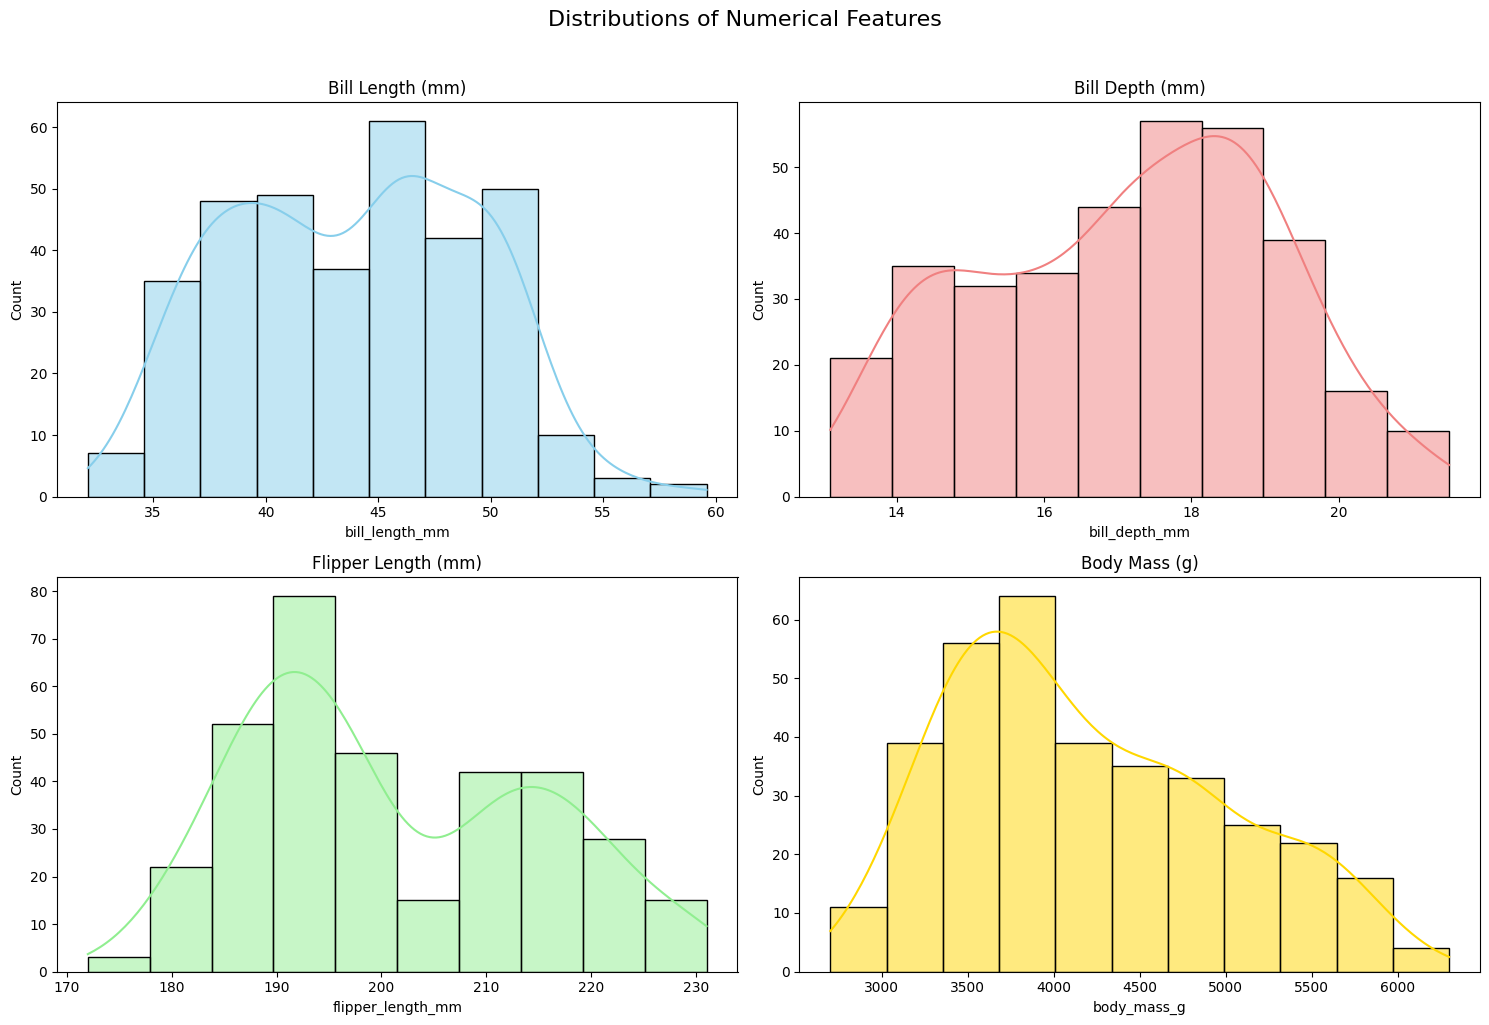

In [11]:
print("\nDistributions of Numerical Features:")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distributions of Numerical Features', y=1.02, fontsize=16)

sns.histplot(penguins_df['bill_length_mm'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Bill Length (mm)')

sns.histplot(penguins_df['bill_depth_mm'], kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Bill Depth (mm)')

sns.histplot(penguins_df['flipper_length_mm'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Flipper Length (mm)')

sns.histplot(penguins_df['body_mass_g'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Body Mass (g)')

plt.tight_layout()
plt.show()


Counts of Categorical Features:


/tmp/ipykernel_12966/2837944469.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=penguins_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_12966/2837944469.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='island', data=penguins_df, ax=axes[1], palette='plasma')
/tmp/ipykernel_12966/2837944469.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=penguins_df, ax=axes[2], palette='magma')


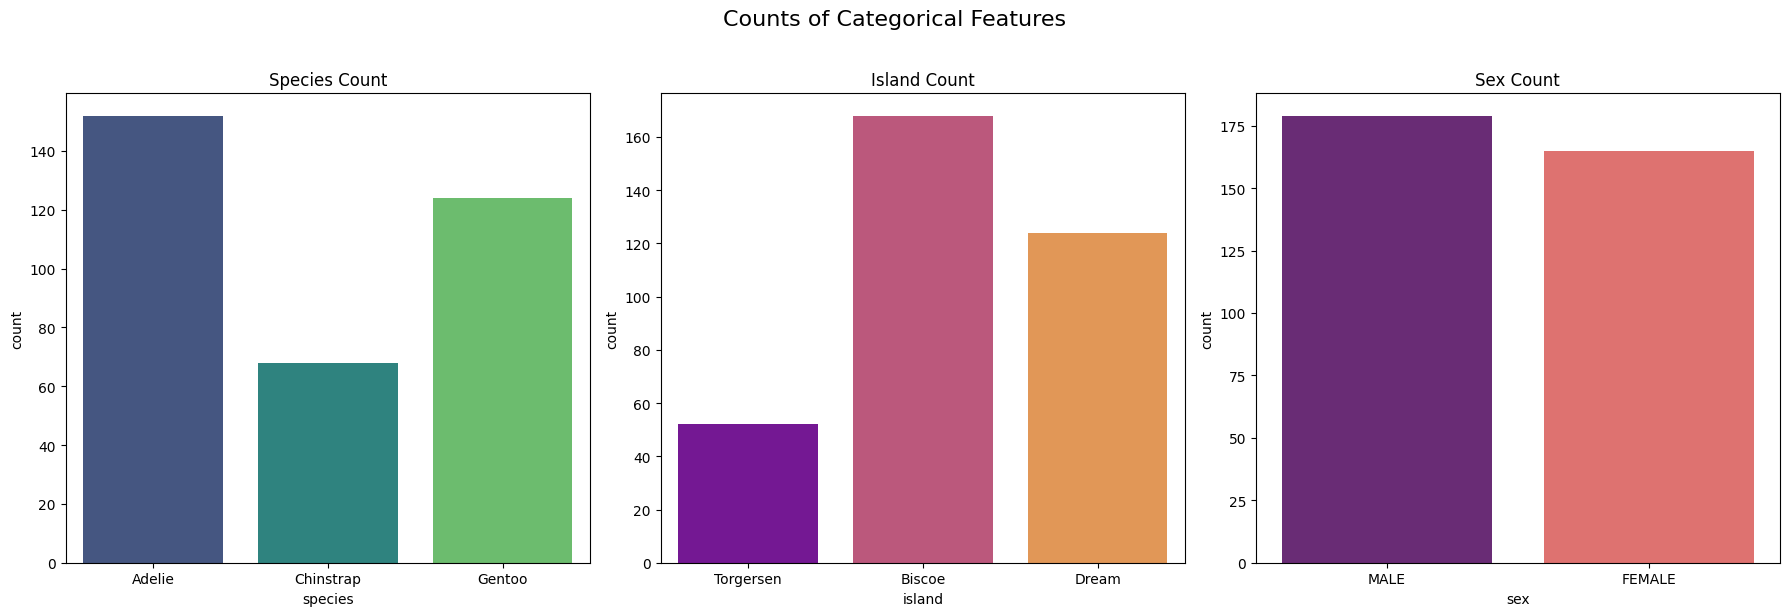

In [12]:
print("\nCounts of Categorical Features:")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Counts of Categorical Features', y=1.02, fontsize=16)

sns.countplot(x='species', data=penguins_df, ax=axes[0], palette='viridis')
axes[0].set_title('Species Count')

sns.countplot(x='island', data=penguins_df, ax=axes[1], palette='plasma')
axes[1].set_title('Island Count')

sns.countplot(x='sex', data=penguins_df, ax=axes[2], palette='magma')
axes[2].set_title('Sex Count')

plt.tight_layout()
plt.show()

### Step 5: Preprocessing and Feature Engineering

Before applying machine learning models, we need to preprocess the data. This involves:
1. Defining the target variable (`species`).
2. Separating features (X) and target (y).
3. Encoding categorical features (`island`, `sex`) using One-Hot Encoding.
4. Scaling numerical features (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) using StandardScaler.
5. Splitting the data into training and testing sets.

In [13]:
# Define target variable (y) and features (X)
X = penguins_df.drop('species', axis=1)
y = penguins_df['species']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.10,18.7,181.0,3750.0,MALE
1,Torgersen,39.50,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.30,18.0,195.0,3250.0,FEMALE
3,Torgersen,44.45,17.3,197.0,4050.0,MALE
4,Torgersen,36.70,19.3,193.0,3450.0,FEMALE



Target (y) head:


,species
0,Adelie
1,Adelie
2,Adelie
3,Adelie
4,Adelie


In [14]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"Numerical Features: {list(numerical_features)}")
print(f"Categorical Features: {list(categorical_features)}")

Numerical Features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical Features: ['island', 'sex']


In [15]:
# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessing pipelines created.")

Preprocessing pipelines created.


In [29]:
# Apply preprocessing to the features
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This is a bit more involved as ColumnTransformer's get_feature_names_out() needs to be called on the preprocessor object
# and depends on scikit-learn version. For simplicity, let's just use the transformed array for now.

print("Features preprocessed successfully. Shape of preprocessed data:", X_preprocessed.shape)

Features preprocessed successfully. Shape of preprocessed data: (344, 9)


In [30]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (275, 9), (275,)
Testing set shape: (69, 9), (69,)


In [31]:
import numpy as np

# Har row ko unique string ya hash mein convert karke overlap check karna
def check_numpy_overlap(train, test):
    # Rows ko contiguous arrays bana kar view karna taake comparison ho sake
    train_view = np.ascontiguousarray(train).view(np.dtype((np.void, train.dtype.itemsize * train.shape[1])))
    test_view = np.ascontiguousarray(test).view(np.dtype((np.void, test.dtype.itemsize * test.shape[1])))

    intersect = np.intersect1d(train_view, test_view)
    return len(intersect)

duplicates = check_numpy_overlap(X_train, X_test)
print(f"Total training samples: {len(X_train)}")
print(f"Total testing samples: {len(X_test)}")
print(f"Common rows found between Train and Test: {duplicates}")

if duplicates > 0:
    print("⚠️ Warning: Data Leakage detected! Train aur Test mein same data points hain.")
else:
    print("✅ No overlap: Train aur Test data bilkul alag hain.")

Total training samples: 275
Total testing samples: 69
Common rows found between Train and Test: 0
✅ No overlap: Train aur Test data bilkul alag hain.


In [32]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Data ko 5 mukhtalif hisson mein baant kar check karein
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_val_score(log_reg_model, X_train, y_train, cv=skf)

print(f"Cross-Validation Accuracies: {cv_results}")
print(f"Average Accuracy: {cv_results.mean():.4f}")
print(f"Standard Deviation: {cv_results.std():.4f}")

Cross-Validation Accuracies: [0.98181818 1.         1.         0.96363636 1.        ]
Average Accuracy: 0.9891
Standard Deviation: 0.0145


Model trained successfully.

--- Logistic Regression Results ---
Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



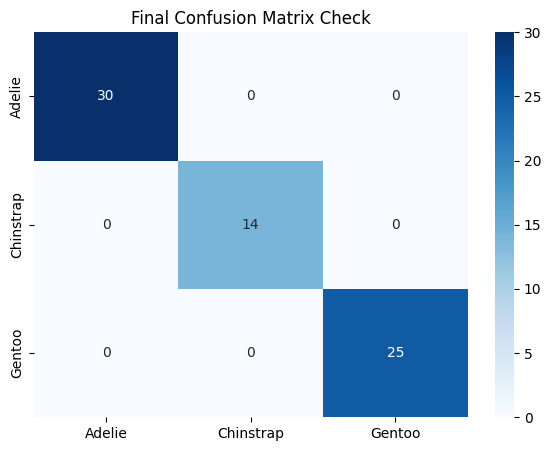

In [25]:
# --- Logistic Regression Model Execution ---

# 1. Initialize the model
# Hum wahi parameters use kar rahe hain jo pehle the
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

# 2. Fit the model on the existing X_train and y_train
log_reg_model.fit(X_train, y_train)
print("Model trained successfully.")

# 3. Predict on the existing X_test
y_pred_log_reg = log_reg_model.predict(X_test)

# 4. Final Results
print("\n--- Logistic Regression Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

# 5. Confusion Matrix to see the actual vs predicted count
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg_model.classes_, yticklabels=log_reg_model.classes_)
plt.title('Final Confusion Matrix Check')
plt.show()

In [34]:
import pandas as pd
import numpy as np

# 1. Pehle check karein ke X mein strings to nahi reh gaye
# Agar X ek DataFrame hai, to 'Island' ya 'Sex' jaise columns ko drop karein
if isinstance(X, pd.DataFrame):
    # Sirf numeric columns rakhein
    X_numeric = X.select_dtypes(include=[np.number])
    print(f"Remaining columns: {X_numeric.columns.tolist()}")
else:
    X_numeric = X

# 2. Ab split karein (X_numeric use karte hue)
X_train_60, X_test_40, y_train_60, y_test_40 = train_test_split(
    X_numeric, y, test_size=0.40, random_state=42, shuffle=True
)

# 3. Model Training
log_reg_6040 = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

# Fit karte waqt error nahi aana chahiye kyunke humne strings nikaal diye hain
log_reg_6040.fit(X_train_60, y_train_60)

# 4. Results
y_pred_40 = log_reg_6040.predict(X_test_40)
print("\n--- Logistic Regression (60/40 Split) Results ---")
print(f"Accuracy Score: {accuracy_score(y_test_40, y_pred_40):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_40, y_pred_40))

Remaining columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

--- Logistic Regression (60/40 Split) Results ---
Accuracy Score: 0.9928

Classification Report:
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        64
   Chinstrap       1.00      1.00      1.00        24
      Gentoo       1.00      0.98      0.99        50

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138



### Step 8: Model Training and Evaluation - K-Nearest Neighbors (KNN)

Now, let's apply the K-Nearest Neighbors (KNN) classifier. KNN is a non-parametric algorithm that classifies a data point based on how its neighbors are classified. We will use a common starting point for the number of neighbors (`n_neighbors`).

After training the model, we'll make predictions on the test set (`X_test`, which is from our initial 80/20 split) and evaluate its performance using accuracy, precision, recall, F1-score, and a confusion matrix.

In [35]:
# Initialize and train the K-Nearest Neighbors model
# Using the previously defined X_train and y_train from the 80/20 split
kNN_model = KNeighborsClassifier(n_neighbors=5) # Starting with 5 neighbors
kNN_model.fit(X_train, y_train)

print("K-Nearest Neighbors model trained successfully.")

K-Nearest Neighbors model trained successfully.



--- K-Nearest Neighbors Model Evaluation ---
Accuracy: 0.9855
Precision: 0.9865
Recall: 0.9855
F1-Score: 0.9856

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69


Confusion Matrix:


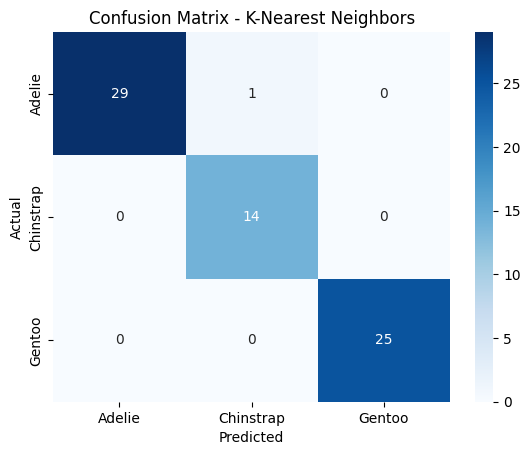

In [36]:
# Make predictions on the test set (from the 80/20 split)
y_pred_knn = kNN_model.predict(X_test)

# Evaluate the model
print("\n--- K-Nearest Neighbors Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=kNN_model.classes_, yticklabels=kNN_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.show()

### Step 9: Model Training and Evaluation - Support Vector Machine (SVM)

Next, let's apply the Support Vector Machine (SVM) classifier. SVMs are powerful and versatile algorithms that can be used for both classification and regression tasks. We will use a basic SVC (Support Vector Classifier) with default parameters for now.

In [37]:
# Initialize and train the Support Vector Machine model
# Using the previously defined X_train and y_train from the 80/20 split
svm_model = SVC(random_state=42) # Using default kernel (rbf) for now
svm_model.fit(X_train, y_train)

print("Support Vector Machine model trained successfully.")

Support Vector Machine model trained successfully.



--- Support Vector Machine Model Evaluation ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


Confusion Matrix:


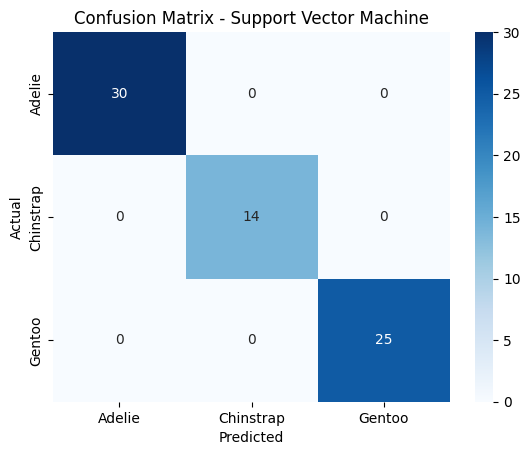

In [38]:
# Make predictions on the test set (from the 80/20 split)
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("\n--- Support Vector Machine Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Support Vector Machine')
plt.show()

### Step 10: Model Training and Evaluation - Decision Tree

Now, let's implement the Decision Tree classifier. Decision trees are non-parametric supervised learning methods used for classification and regression. The goal is to create a model that predicts the value of a target variable by learning simple decision rules inferred from the data features. We'll start with a basic Decision Tree Classifier.

In [39]:
# Initialize and train the Decision Tree model
# Using the previously defined X_train and y_train from the 80/20 split
dt_model = DecisionTreeClassifier(random_state=42) # Using default parameters for now
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.



--- Decision Tree Model Evaluation ---
Accuracy: 0.9855
Precision: 0.9861
Recall: 0.9855
F1-Score: 0.9855

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.99        69
   macro avg       0.99      0.99      0.99        69
weighted avg       0.99      0.99      0.99        69


Confusion Matrix:


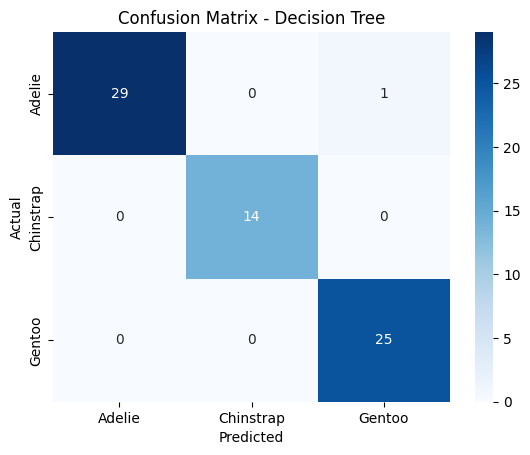

In [40]:
# Make predictions on the test set (from the 80/20 split)
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("\n--- Decision Tree Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### Visualizing the Decision Tree

To understand how the Decision Tree makes its classifications, we can visualize its structure. This plot will show the splits based on different features and the resulting classifications.

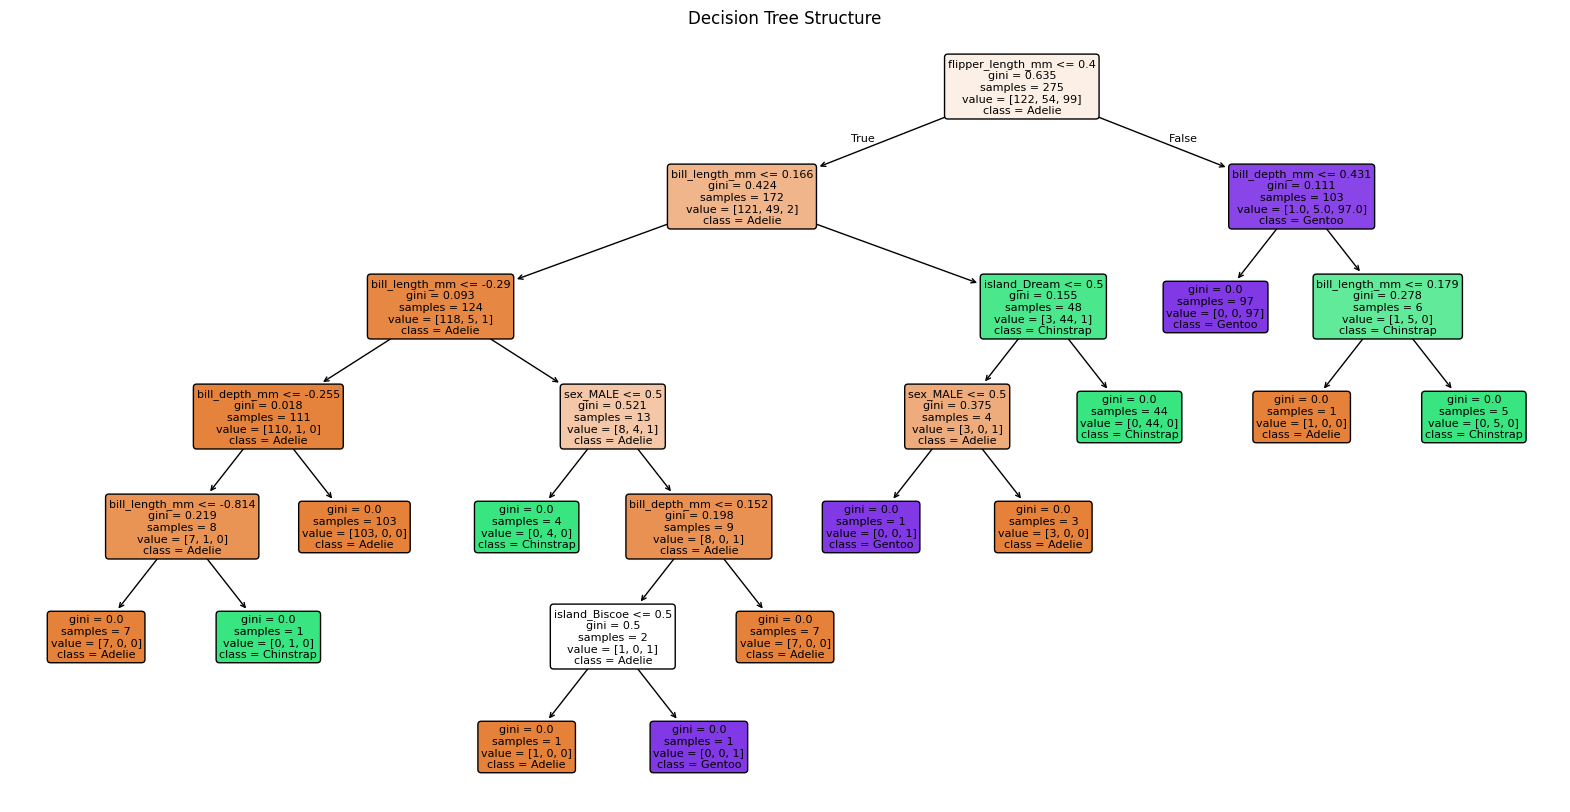

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get feature names after preprocessing
# This requires knowing the order of features after ColumnTransformer
# For numerical features, it's straightforward. For one-hot encoded, it gets tricky.
# Let's reconstruct them properly.

# Get names for numerical features (scaled)
num_feature_names = list(numerical_features)

# Get names for categorical features (one-hot encoded)
# The 'onehot' transformer is part of the 'cat' pipeline in the preprocessor
cat_ohe_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# Combine all feature names in the correct order
all_feature_names = num_feature_names + list(cat_ohe_feature_names)

plt.figure(figsize=(20, 10))
plot_tree(dt_model,
          filled=True,
          feature_names=all_feature_names,
          class_names=dt_model.classes_,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Structure')
plt.show()